## Import libraries

In [ ]:
import os
import re

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Data distribution
It should be noted that RAF-DB is characterized by an uneven distribution of emotions (some classes, such as negative emotions, are significantly underrepresented). Therefore, in practice, it is necessary to use data balancing methods to obtain more reliable classification results.


Detailed Counts:
   Subset Class ID Class Name  Count
0   train        1   Surprise   1225
1   train        2       Fear    256
2   train        3    Disgust    687
3   train        4        Joy   4606
4   train        5    Sadness   1841
5   train        6      Anger    611
6   train        7    Neutral   2315
7    test        1   Surprise    315
8    test        2       Fear     66
9    test        3    Disgust    159
10   test        4        Joy   1137
11   test        5    Sadness    442
12   test        6      Anger    144
13   test        7    Neutral    612


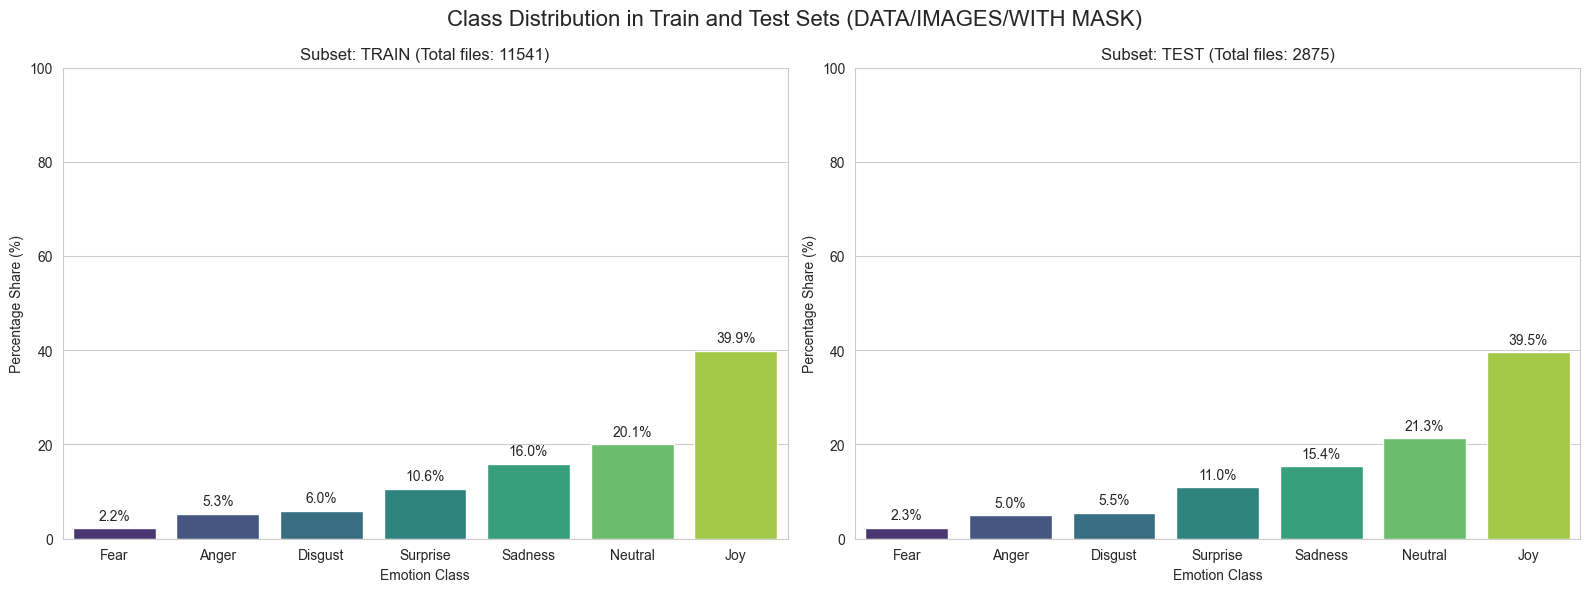

In [ ]:
# === CONFIGURATION & CONSTANTS ===
TARGET_DICT = {
    '1' : 'Surprise',
    '2' : 'Fear',
    '3' : 'Disgust',
    '4' : 'Joy',
    '5' : 'Sadness',
    '6' : 'Anger',
    '7' : 'Neutral'
}
root_path = os.path.join('DATA', 'IMAGES', 'WITH MASK')
stats = []
subsets = ['train', 'test']

# === DATA GATHERING ===
for subset in subsets:
    subset_path = os.path.join(root_path, subset)
    if not os.path.exists(subset_path):
        print(f"Warning: Folder not found {subset_path}")
        continue
    for target_id, class_name in TARGET_DICT.items():
        class_folder = os.path.join(subset_path, target_id)
        count = 0
        if os.path.exists(class_folder):
            count = len([f for f in os.listdir(class_folder) if os.path.isfile(os.path.join(class_folder, f))])
        stats.append({
            'Subset': subset,
            'Class ID': target_id,
            'Class Name': class_name,
            'Count': count
        })
df = pd.DataFrame(stats)
print("\nDetailed Counts:")
print(df)
# === VISUALIZATION ===
if not df.empty:
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Class Distribution in Train and Test Sets (DATA/IMAGES/WITH MASK)', fontsize=16)
    for i, subset in enumerate(subsets):
        subset_data = df[df['Subset'] == subset].copy()
        total_files = subset_data['Count'].sum()
        if total_files > 0:
            subset_data['Percentage'] = (subset_data['Count'] / total_files) * 100
            subset_data = subset_data.sort_values(by='Percentage', ascending=True)
            order_list = subset_data['Class Name'].tolist()
            sns.barplot(
                data=subset_data, 
                x='Class Name', 
                y='Percentage', 
                hue='Class Name',
                legend=False,
                ax=axes[i], 
                palette='viridis',
                order=order_list
            )
            axes[i].set_title(f'Subset: {subset.upper()} (Total files: {total_files})')
            axes[i].set_ylabel('Percentage Share (%)')
            axes[i].set_xlabel('Emotion Class')
            axes[i].set_ylim(0, 100)
            for p in axes[i].patches:
                axes[i].annotate(f'{p.get_height():.1f}%', 
                                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                                 ha='center', va='center', 
                                 xytext=(0, 9), 
                                 textcoords='offset points')
        else:
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center')
            axes[i].set_title(f'Subset: {subset.upper()}')
    plt.tight_layout()
    plt.show()
else:
    print("No data to display. Please check the folder paths.")

## Data visualization
- face photos
- face photos covered with masks
- vector mesh of the entire face
- vector mesh of the upper part of the face

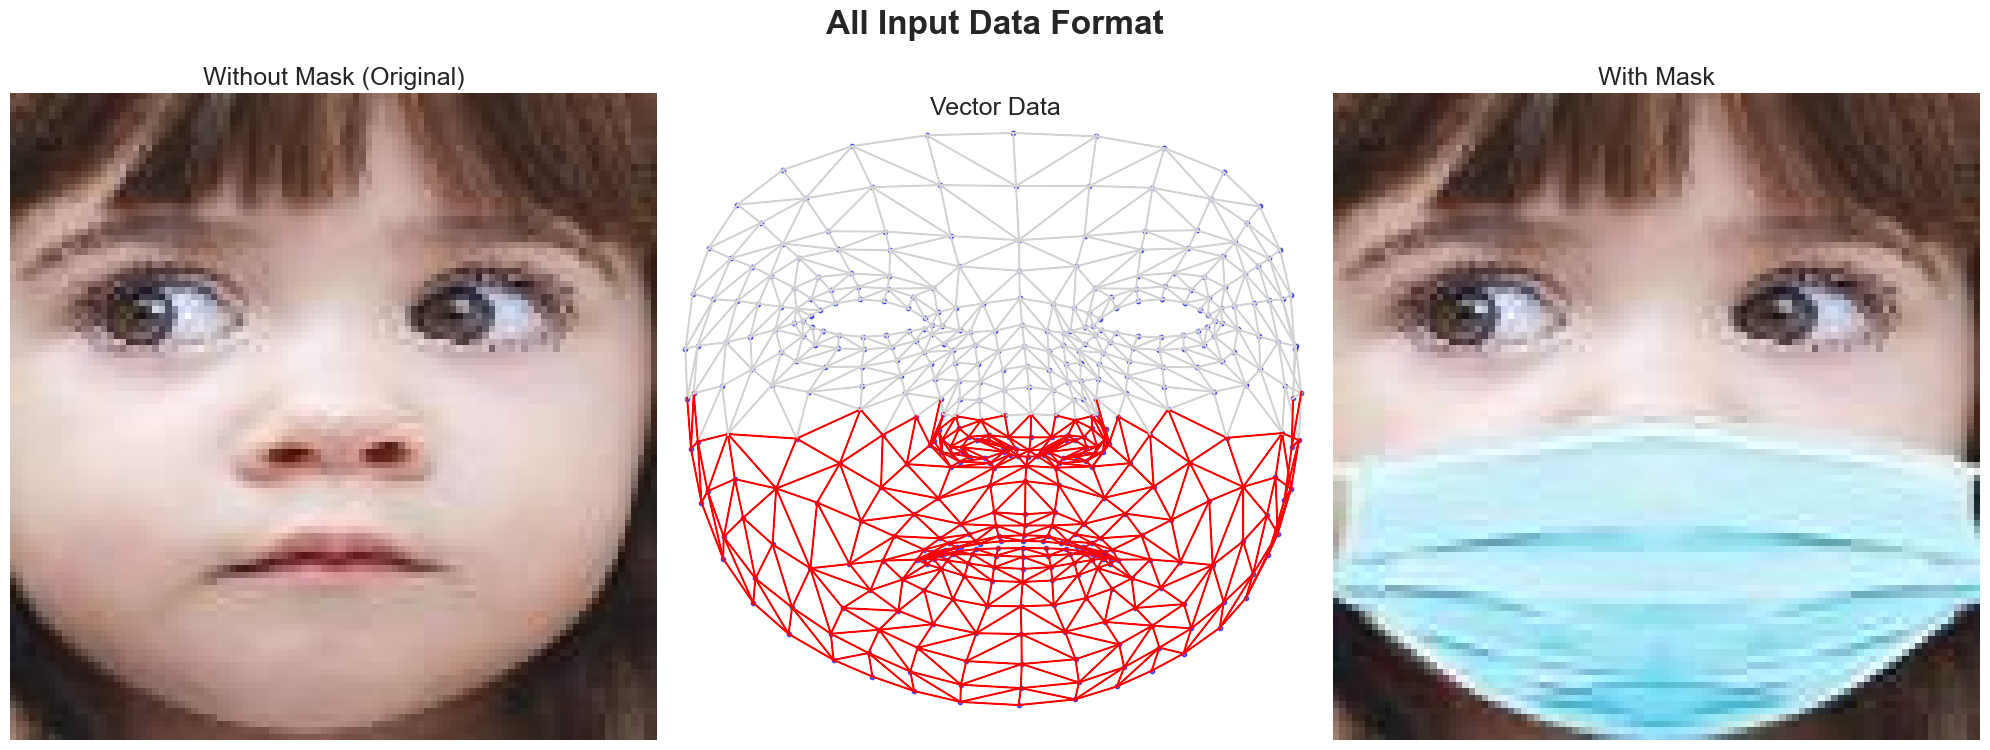

In [10]:
# === CONFIGURATION & CONSTANTS ===
CSV_PATH = 'DATA/VECTORS AND LANDMARKS/without_mask_test.csv'
IMG_WITHOUT_MASK_PATH = 'DATA/IMAGES/WITHOUT MASK/test/1/test_0002_aligned.jpg'
IMG_WITH_MASK_PATH = 'DATA/IMAGES/WITH MASK/test/1/test_0002_aligned.jpg'

# === DATA LOADING & PROCESSING ===
df = pd.read_csv(CSV_PATH)
row = df.iloc[0]
landmarks = np.array([
    [row[f'landmark_{i}_x'], row[f'landmark_{i}_y']] for i in range(468)
])
# === VIZUALIZATION SETUP ===
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('All Input Data Format', fontsize=24, fontweight='bold')
# === PANEL 1: ORYGINAL IMAGE ===
ax_img1 = axes[0]
img1 = mpimg.imread(IMG_WITHOUT_MASK_PATH)
ax_img1.imshow(img1)
ax_img1.set_title("Without Mask (Original)", fontsize=18)
ax_img1.axis('off')
# === PANEL 2: VECTOR VIZUALIZATION ===
ax_viz = axes[1]
ax_viz.scatter(landmarks[:, 0], -landmarks[:, 1], s=10, c='blue', alpha=0.6)
edge_cols = [c for c in df.columns if c.startswith('edge_')]
pattern = re.compile(r'edge_(\d+)_(\d+)')
for edge in edge_cols:
    match = pattern.match(edge)
    if not match:
        continue
    idx1, idx2 = int(match.group(1)), int(match.group(2))
    p1, p2 = landmarks[idx1], landmarks[idx2]
    x1, y1 = p1[0], -p1[1]
    x2, y2 = p2[0], -p2[1]
    dx = x2 - x1
    dy = y2 - y1
    mid_y = (y1 + y2) / 2
    color = 'red' if -1 < mid_y < -0.5 else 'lightgray'
    ax_viz.arrow(
        x1, y1, dx, dy,
        head_width=0.001,
        head_length=0.003,
        fc=color, ec=color, linewidth=1
    )
ax_viz.set_xlim(-0.1, 1)
ax_viz.set_ylim(-1, 0)
ax_viz.set_title("Vector Data", fontsize=18)
ax_viz.set_aspect('equal')
ax_viz.axis('off')
# === PANEL 3: MASKED IMAGE ===
ax_img2 = axes[2]
img2 = mpimg.imread(IMG_WITH_MASK_PATH)
ax_img2.imshow(img2)
ax_img2.set_title("With Mask", fontsize=18)
ax_img2.axis('off')
# === SHOW PLOTS ===
plt.tight_layout()
plt.show()

## Vector data correlation with labels

Found 7 unique targets.
Processing: ['1', '2', '3', '4', '5', '6', '7']
Analyzing: Surprise (ID: 1)...
Analyzing: Fear (ID: 2)...
Analyzing: Disgust (ID: 3)...
Analyzing: Joy (ID: 4)...
Analyzing: Sadness (ID: 5)...
Analyzing: Anger (ID: 6)...
Analyzing: Neutral (ID: 7)...


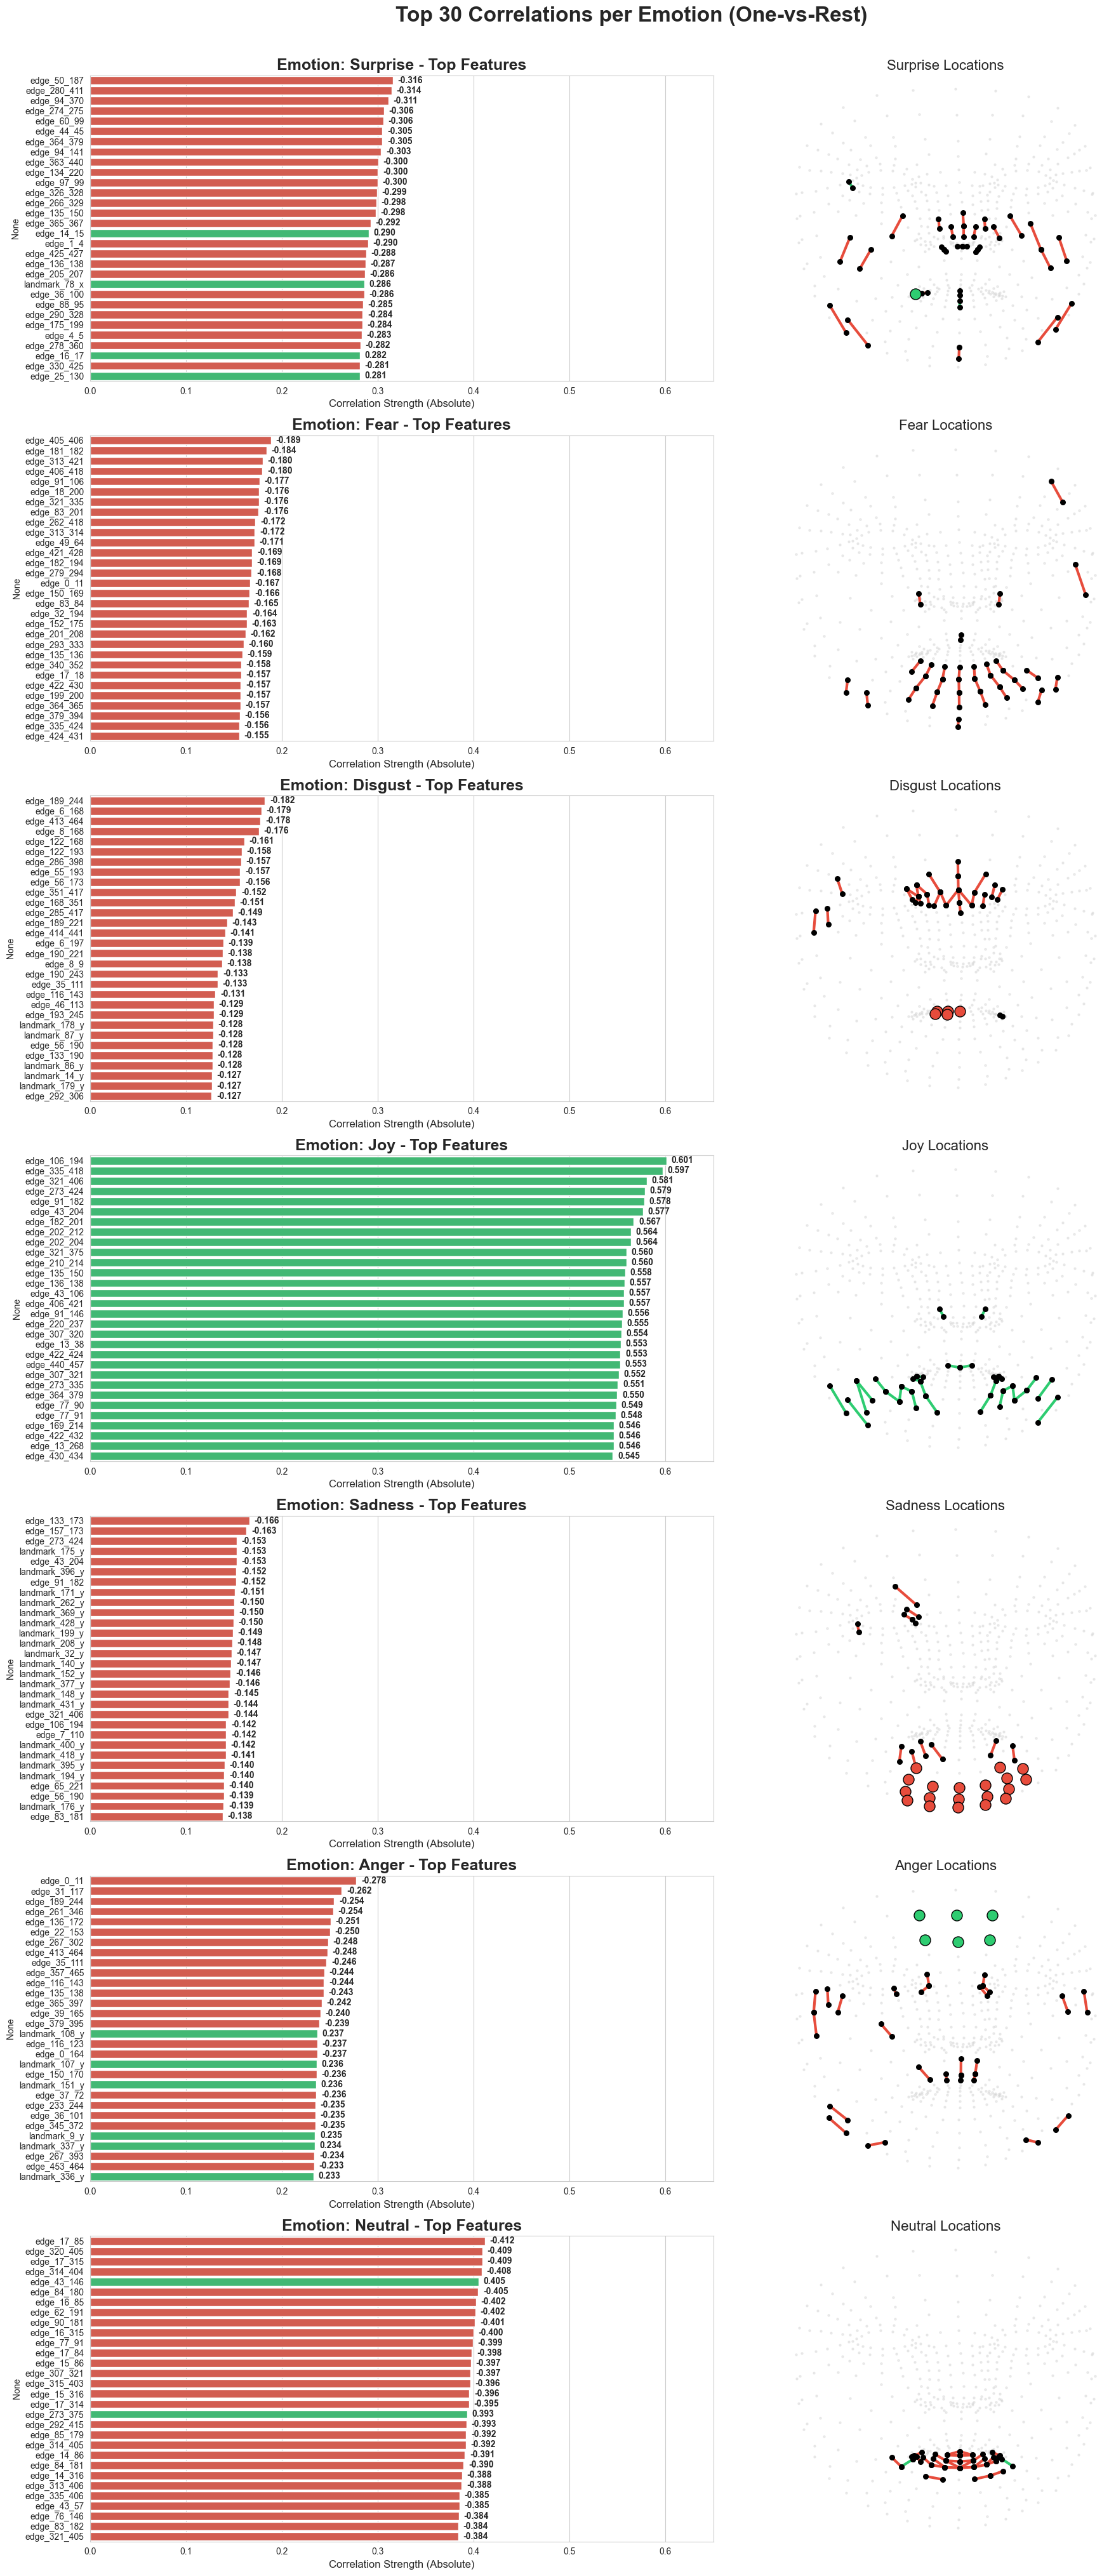

In [11]:
# === CONFIGURATION & CONSTANTS ===
CSV_PATH = 'DATA/VECTORS AND LANDMARKS/without_mask_test.csv'
TOP_N = 30
TARGET_DICT = {
    '1': 'Surprise',
    '2': 'Fear',
    '3': 'Disgust',
    '4': 'Joy',
    '5': 'Sadness',
    '6': 'Anger',
    '7': 'Neutral'
}

# === DATA LOADING & VALIDATION ===
if not os.path.exists(CSV_PATH):
    print(f"Error: File not found {CSV_PATH}")
    exit()
df = pd.read_csv(CSV_PATH)
if 'target' in df.columns:
    df['target'] = df['target'].astype(str)
else:
    print("Error: 'target' column missing.")
    exit()
# === PREPROCESSING ===
row_geom = df.iloc[0]
landmarks = np.array([
    [row_geom.get(f'landmark_{i}_x', np.nan), 
     row_geom.get(f'landmark_{i}_y', np.nan)]
    for i in range(468)
])
targets_to_process = sorted(df['target'].unique())
numeric_df = df.select_dtypes(include='number')
print(f"Found {len(targets_to_process)} unique targets.")
print(f"Processing: {targets_to_process}")
# === VISUALIZATION SETUP ===
fig, axes = plt.subplots(
    len(targets_to_process), 2, 
    figsize=(20, 6 * len(targets_to_process))
)
fig.suptitle(
    f'Top {TOP_N} Correlations per Emotion (One-vs-Rest)', 
    fontsize=24, fontweight='bold', y=0.995
)
# === ANALYSIS & PLOTTING LOOP ===
for i, current_target in enumerate(targets_to_process):
    target_name = TARGET_DICT.get(current_target, f"Unknown ({current_target})")
    print(f"Analyzing: {target_name} (ID: {current_target})...")
    if len(targets_to_process) == 1:
        ax_bar, ax_face = axes[0], axes[1]
    else:
        ax_bar, ax_face = axes[i, 0], axes[i, 1]
    binary_target = (df['target'] == current_target).astype(int)
    correlations = numeric_df.corrwith(binary_target)
    pattern_edge_check = re.compile(r'edge_(\d+)_(\d+)')
    sorted_candidates = correlations.abs().sort_values(ascending=False)
    final_features_list = []
    for feat_name, val in sorted_candidates.items():
        match = pattern_edge_check.match(feat_name)
        if match:
            idx1, idx2 = sorted([int(match.group(1)), int(match.group(2))])
            final_features_list.append(feat_name)
        else:
            final_features_list.append(feat_name)
        if len(final_features_list) >= TOP_N:
            break
    top_features = correlations.loc[final_features_list]
    top_abs = top_features.abs()
    # === BAR CHART VISUALIZATION ===
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_features.values]
    sns.barplot(
        x=top_abs.values,
        y=top_abs.index,
        ax=ax_bar,
        palette=colors,
        hue=top_abs.index,
        legend=False
    )
    ax_bar.set_title(f'Emotion: {target_name} - Top Features', fontsize=18, fontweight='bold')
    ax_bar.set_xlabel('Correlation Strength (Absolute)', fontsize=12)
    ax_bar.set_xlim(0, 0.65)
    for p, val in zip(ax_bar.patches, top_features.values):
        width = p.get_width()
        ax_bar.text(
            width + 0.005,
            p.get_y() + p.get_height() / 2,
            f'{val:.3f}',
            ha='left', va='center', fontsize=10, fontweight='bold'
        )
    # === FACE LANDMARK VISUALIZATION ===
    ax_face.scatter(landmarks[:, 0], -landmarks[:, 1], s=5, c='lightgray', alpha=0.4)
    pattern_edge = re.compile(r'edge_(\d+)_(\d+)')
    pattern_landmark = re.compile(r'landmark_(\d+)_')
    for feat_name in final_features_list:
        corr_val = correlations[feat_name]
        color = '#2ecc71' if corr_val > 0 else '#e74c3c'
        # === Case 1: Edge features ===
        match_edge = pattern_edge.match(feat_name)
        if match_edge:
            idx1, idx2 = int(match_edge.group(1)), int(match_edge.group(2))
            p1, p2 = landmarks[idx1], landmarks[idx2]
            if not (np.isnan(p1).any() or np.isnan(p2).any()):
                ax_face.plot(
                    [p1[0], p2[0]], [-p1[1], -p2[1]], 
                    color=color, linewidth=3, zorder=10
                )
                ax_face.scatter([p1[0], p2[0]], [-p1[1], -p2[1]], s=30, c='black', zorder=11)
        # === Case 2: Individual Landmark features ===
        match_lm = pattern_landmark.match(feat_name)
        if match_lm:
            idx = int(match_lm.group(1))
            p = landmarks[idx]
            if not np.isnan(p).any():
                ax_face.scatter(p[0], -p[1], s=150, c=color, edgecolors='black', zorder=12)
    ax_face.set_title(f'{target_name} Locations', fontsize=16)
    ax_face.set_aspect('equal')
    ax_face.axis('off')
# === SHOW PLOTS ===
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()